**Task 3 - Instagram Dataset**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better plots in Colab
%matplotlib inline
sns.set(style="whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


In [16]:
import pandas as pd

# Load CSV files using raw GitHub URLs
comments = pd.read_csv("https://raw.githubusercontent.com/AkshayaB-it/Alfido-Tech-Internship/main/Task-3-Instagram-Social-Media-Analysis/comments.csv")
follows = pd.read_csv("https://raw.githubusercontent.com/AkshayaB-it/Alfido-Tech-Internship/main/Task-3-Instagram-Social-Media-Analysis/follows.csv")
likes = pd.read_csv("https://raw.githubusercontent.com/AkshayaB-it/Alfido-Tech-Internship/main/Task-3-Instagram-Social-Media-Analysis/likes.csv")
photo_tags = pd.read_csv("https://raw.githubusercontent.com/AkshayaB-it/Alfido-Tech-Internship/main/Task-3-Instagram-Social-Media-Analysis/photo_tags.csv")
photos = pd.read_csv("https://raw.githubusercontent.com/AkshayaB-it/Alfido-Tech-Internship/main/Task-3-Instagram-Social-Media-Analysis/photos.csv")
tags = pd.read_csv("https://raw.githubusercontent.com/AkshayaB-it/Alfido-Tech-Internship/main/Task-3-Instagram-Social-Media-Analysis/tags.csv")
users = pd.read_csv("https://raw.githubusercontent.com/AkshayaB-it/Alfido-Tech-Internship/main/Task-3-Instagram-Social-Media-Analysis/users.csv")

# Quick check
print("Comments dataset shape:", comments.shape)
print("Users dataset shape:", users.shape)


Comments dataset shape: (7488, 8)
Users dataset shape: (100, 6)


In [17]:
# Strip spaces from all columns after loading CSVs
comments.columns = comments.columns.str.strip()
follows.columns = follows.columns.str.strip()
likes.columns = likes.columns.str.strip()
photo_tags.columns = photo_tags.columns.str.strip()
photos.columns = photos.columns.str.strip()
tags.columns = tags.columns.str.strip()
users.columns = users.columns.str.strip()


In [18]:
# Explore Datasets

datasets = [comments, follows, likes, photo_tags, photos, tags, users]
dataset_names = ['comments','follows','likes','photo_tags','photos','tags','users']

for name, df in zip(dataset_names, datasets):
    print(f"\n--- {name} ---")
    print(df.head())
    print(df.info())
    print(df.isnull().sum())
    print(df.describe())



--- comments ---
   id                 comment  User  id  Photo id created Timestamp  \
0   1         unde at dolorem         2         1  13-04-2023 08:04   
1   2         quae ea ducimus         3         1  13-04-2023 08:04   
2   3      alias a voluptatum         5         1  13-04-2023 08:04   
3   4    facere suscipit sunt        14         1  13-04-2023 08:04   
4   5  totam eligendi quaerat        17         1  13-04-2023 08:04   

  posted date emoji used  Hashtags used count  
0    April 14        yes                    1  
1    April 14         no                    2  
2    April 14         no                    4  
3    April 14        yes                    2  
4    April 14        yes                    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   7488 non-null   int64 
 1   comment  

Top 10 Users by Number of Posts:
user ID
23    12
88    11
59    10
86     9
29     8
58     8
77     6
11     5
1      5
6      5
Name: count, dtype: int64


C:\Users\B AKSHAYA\AppData\Local\Temp\ipykernel_4536\2221101048.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_users.index, y=top_users.values, palette='viridis')


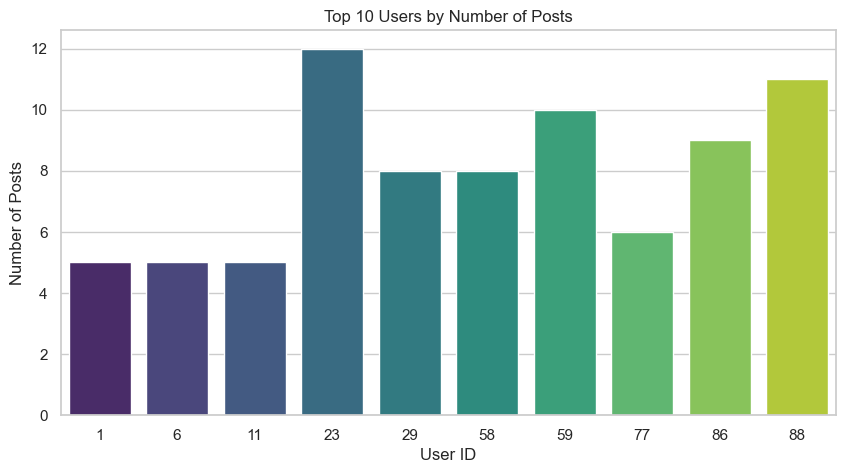

In [19]:
# Top Users by Number of Posts

# Strip column names to remove extra spaces
photos.columns = photos.columns.str.strip()

# Detect the user column automatically
user_col = [col for col in photos.columns if 'user' in col.lower()]
if len(user_col) == 0:
    raise KeyError("No user column found in photos.csv")
user_col = user_col[0]

# Count posts per user
top_users = photos[user_col].value_counts().head(10)

# Display the results
print("Top 10 Users by Number of Posts:")
print(top_users)

# Plot the top 10 users
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=top_users.index, y=top_users.values, palette='viridis')
plt.title("Top 10 Users by Number of Posts")
plt.xlabel("User ID")
plt.ylabel("Number of Posts")
plt.show()


Top 10 Most Liked Posts:
photo
145    48
127    43
182    43
123    42
147    41
52     41
192    41
174    41
61     41
30     41
Name: count, dtype: int64


C:\Users\B AKSHAYA\AppData\Local\Temp\ipykernel_4536\2398885424.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_liked_posts.index, y=top_liked_posts.values, palette='magma')


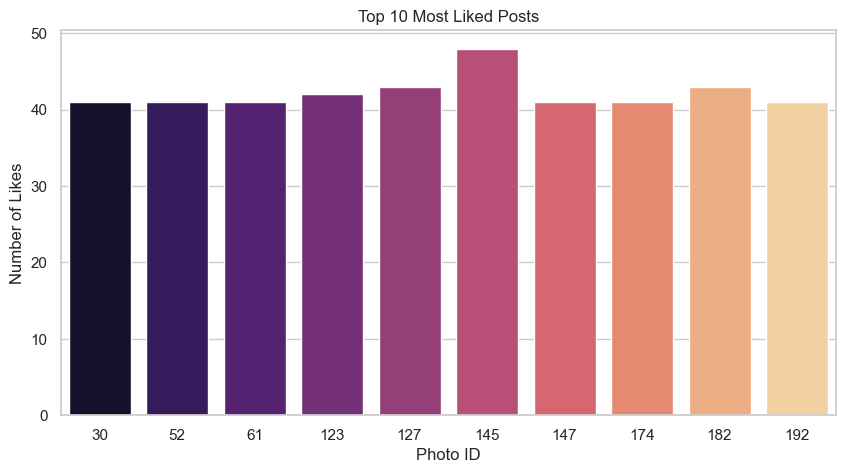

In [20]:
# Most Liked post

# Auto-detect photo_id column in likes
photo_col = [col for col in likes.columns if 'photo' in col.lower()][0]

# Count likes per photo
top_liked_posts = likes[photo_col].value_counts().head(10)
print("Top 10 Most Liked Posts:")
print(top_liked_posts)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=top_liked_posts.index, y=top_liked_posts.values, palette='magma')
plt.title("Top 10 Most Liked Posts")
plt.xlabel("Photo ID")
plt.ylabel("Number of Likes")
plt.show()


Top 10 Most Followed Users:
followee
1     77
25    77
34    77
7     77
29    77
23    77
80    77
77    77
81    77
90    77
Name: follower, dtype: int64


C:\Users\B AKSHAYA\AppData\Local\Temp\ipykernel_4536\2788613920.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=followers_count.index, y=followers_count.values, palette='coolwarm')


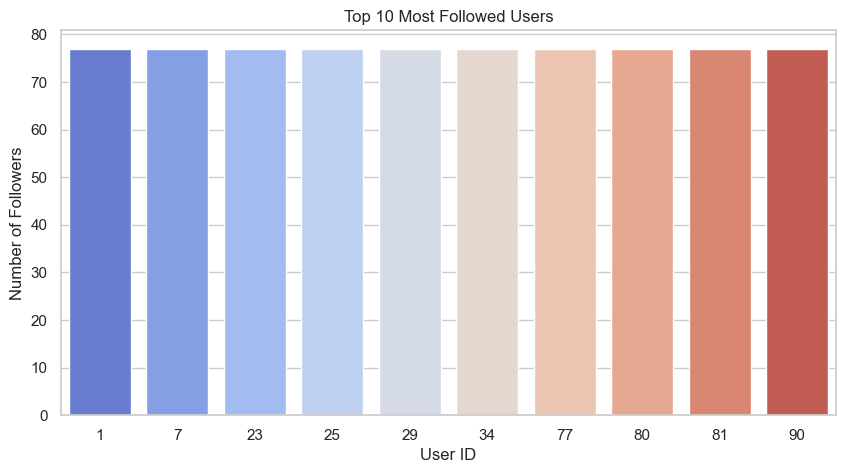

In [21]:
# Most Followed Users

# Auto-detect follower and followed columns
follower_col = [col for col in follows.columns if 'follower' in col.lower()][0]
followed_col = [col for col in follows.columns if 'follow' in col.lower() and col.lower() not in [c.lower() for c in [follower_col]]][0]

# Count followers per user
followers_count = follows.groupby(followed_col)[follower_col].count().sort_values(ascending=False).head(10)
print("Top 10 Most Followed Users:")
print(followers_count)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=followers_count.index, y=followers_count.values, palette='coolwarm')
plt.title("Top 10 Most Followed Users")
plt.xlabel("User ID")
plt.ylabel("Number of Followers")
plt.show()


photo_tags columns: ['photo', 'tag ID', 'user id']
tags columns: ['id', 'tag text', 'created time', 'location']


C:\Users\B AKSHAYA\AppData\Local\Temp\ipykernel_4536\1777868669.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tag_names, y=top_tags.values, palette='plasma')


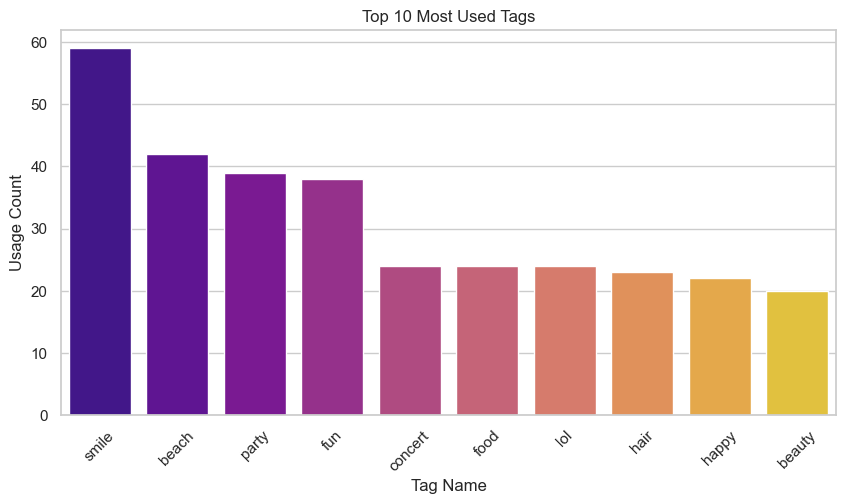

Top 10 Most Used Tags:
tag ID
21      smile
20      beach
17      party
13        fun
18    concert
5        food
11        lol
15       hair
12      happy
8      beauty
Name: tag text, dtype: object


In [22]:
# Most Used Tags

# Check columns
print("photo_tags columns:", photo_tags.columns.tolist())
print("tags columns:", tags.columns.tolist())

# Auto-detect photo_id and tag_id columns in photo_tags
photo_col = [col for col in photo_tags.columns if 'photo' in col.lower()][0]
tag_col_photo_tags = [col for col in photo_tags.columns if 'tag' in col.lower()][0]

# Count tag usage
top_tags = photo_tags[tag_col_photo_tags].value_counts().head(10)

# Auto-detect tag_id and tag name columns in tags.csv
tag_id_col = [col for col in tags.columns if 'id' in col.lower() or 'tag' in col.lower()][0]
possible_name_cols = [col for col in tags.columns if col != tag_id_col]

if len(possible_name_cols) == 0:
    raise KeyError("Cannot detect tag name column in tags.csv. Check the column names above.")

tag_name_col = possible_name_cols[0]  # pick the first column that is not the ID

# Map tag names from tags.csv
top_tag_names = tags.set_index(tag_id_col).loc[top_tags.index][tag_name_col]

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=top_tag_names, y=top_tags.values, palette='plasma')
plt.title("Top 10 Most Used Tags")
plt.xlabel("Tag Name")
plt.ylabel("Usage Count")
plt.xticks(rotation=45)
plt.show()

# Display top tags
print("Top 10 Most Used Tags:")
print(top_tag_names)


In [23]:
# Average Likes and Comments per Post

# Auto-detect photo_id columns
photo_col_likes = [col for col in likes.columns if 'photo' in col.lower()][0]
photo_col_comments = [col for col in comments.columns if 'photo' in col.lower()][0]

# Group by photo and count likes and comments
likes_per_post = likes.groupby(photo_col_likes).size()
comments_per_post = comments.groupby(photo_col_comments).size()

# Combine into a DataFrame
engagement = pd.DataFrame({
    'likes': likes_per_post,
    'comments': comments_per_post
}).fillna(0)

# Display averages
print("Average Likes per Post:", engagement['likes'].mean())
print("Average Comments per Post:", engagement['comments'].mean())


Average Likes per Post: 34.17120622568093
Average Comments per Post: 29.136186770428015


Top 10 Commenters:
User  id
5     257
14    257
36    257
24    257
21    257
54    257
41    257
91    257
76    257
71    257
Name: count, dtype: int64


C:\Users\B AKSHAYA\AppData\Local\Temp\ipykernel_4536\2633596043.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_commenters.index, y=top_commenters.values, palette='Blues_r')


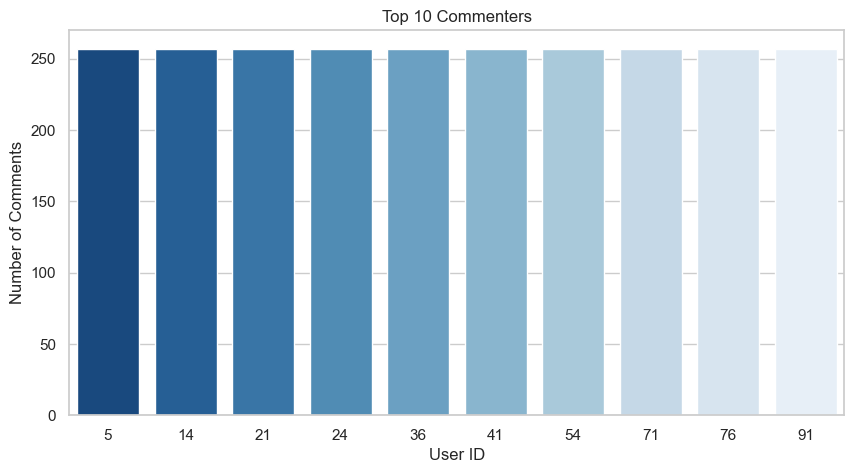

In [24]:
# Top Commenters

# Auto-detect user column in comments
user_col_comments = [col for col in comments.columns if 'user' in col.lower()][0]

# Count comments per user
top_commenters = comments[user_col_comments].value_counts().head(10)
print("Top 10 Commenters:")
print(top_commenters)

# Plot top commenters
plt.figure(figsize=(10,5))
sns.barplot(x=top_commenters.index, y=top_commenters.values, palette='Blues_r')
plt.title("Top 10 Commenters")
plt.xlabel("User ID")
plt.ylabel("Number of Comments")
plt.show()


Top 10 Posts by Total Engagement:
     likes  comments  total_engagement
13      40        39                79
145     48        27                75
147     41        34                75
118     39        35                74
227     39        35                74
196     38        35                73
225     37        36                73
127     43        30                73
123     42        31                73
153     40        32                72


C:\Users\B AKSHAYA\AppData\Local\Temp\ipykernel_4536\1656143887.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_engagement_posts.index, y=top_engagement_posts['total_engagement'], palette='viridis')


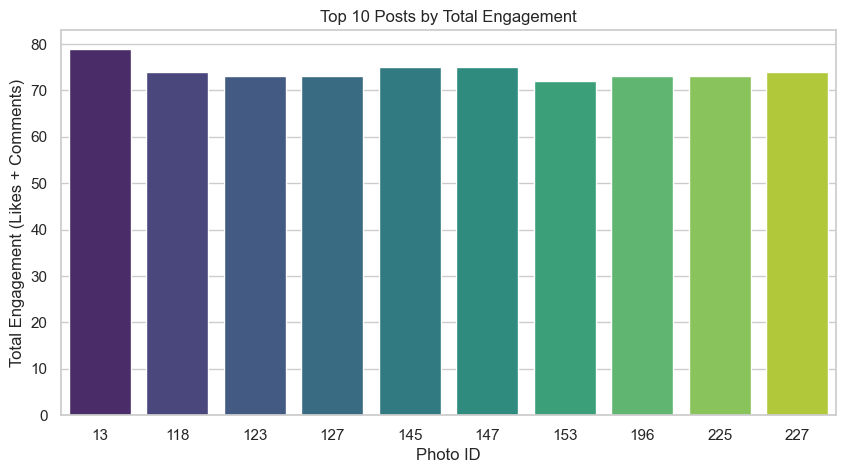

In [25]:
#  Posts with Highest Engagement

# Total engagement = likes + comments
engagement['total_engagement'] = engagement['likes'] + engagement['comments']

# Top 10 posts by total engagement
top_engagement_posts = engagement.sort_values('total_engagement', ascending=False).head(10)
print("Top 10 Posts by Total Engagement:")
print(top_engagement_posts)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=top_engagement_posts.index, y=top_engagement_posts['total_engagement'], palette='viridis')
plt.title("Top 10 Posts by Total Engagement")
plt.xlabel("Photo ID")
plt.ylabel("Total Engagement (Likes + Comments)")
plt.show()


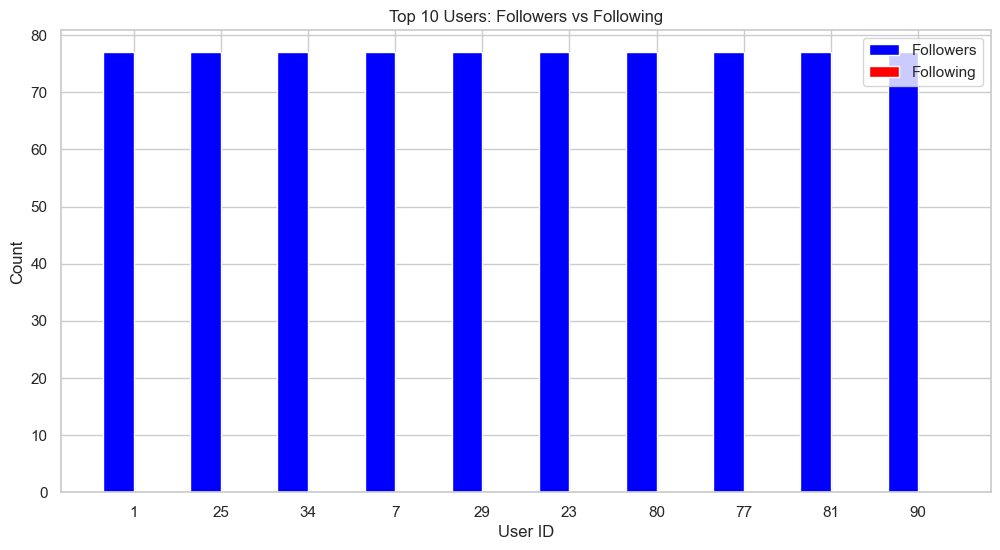

Top 10 Users by Followers:
    followers  following
1          77        0.0
25         77        0.0
34         77        0.0
7          77        0.0
29         77        0.0
23         77        0.0
80         77        0.0
77         77        0.0
81         77        0.0
90         77        0.0


In [26]:
# Follower vs Following Analysis

# Auto-detect follower and followed columns
follower_candidates = [col for col in follows.columns if 'follower' in col.lower()]
followed_candidates = [col for col in follows.columns if 'follow' in col.lower() and col.lower() not in [c.lower() for c in follower_candidates]]

if len(follower_candidates) == 0 or len(followed_candidates) == 0:
    raise KeyError("Cannot detect follower/followed columns automatically. Check follows.csv columns.")

follower_col = follower_candidates[0]
followed_col = followed_candidates[0]

# Count followers and followings
followers_count = follows.groupby(followed_col)[follower_col].count()
following_count = follows.groupby(follower_col)[followed_col].count()

# Combine into a DataFrame
followers_vs_following = pd.DataFrame({
    'followers': followers_count,
    'following': following_count
}).fillna(0)

# Top 10 users by followers
top_followers = followers_vs_following.sort_values('followers', ascending=False).head(10)

# Plot side-by-side bars
import numpy as np

x = np.arange(len(top_followers))
width = 0.35  # width of the bars

plt.figure(figsize=(12,6))
plt.bar(x - width/2, top_followers['followers'], width, label='Followers', color='blue')
plt.bar(x + width/2, top_followers['following'], width, label='Following', color='red')

plt.xticks(x, top_followers.index)
plt.xlabel("User ID")
plt.ylabel("Count")
plt.title("Top 10 Users: Followers vs Following")
plt.legend()
plt.show()

# Display top followers DataFrame
print("Top 10 Users by Followers:")
print(top_followers)


In [27]:
# =========================================
#  Project Completion
# =========================================

print("✅ Instagram Social Media Analysis Complete! Notebook ready for GitHub submission.")


✅ Instagram Social Media Analysis Complete! Notebook ready for GitHub submission.
